In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# ── CONFIG ──────────────────────────────────────────────────────────
csv_path           = '/content/datanew.csv'
model_save_path    = '/content/mlp_angle_model.joblib'
weights_save_path  = '/content/weights_biases.txt'
# ────────────────────────────────────────────────────────────────────

# 1) Load the data
df = pd.read_csv("/content/datanew.csv")
print("Data loaded. Shape:", df.shape)

# 2) Prepare features and labels
# Columns: 'Raw', 'Smoothed', 'Angle'
X = df[['timestamp', 'magnitude', 'Smoothed' , 'frequency']].values.astype(float)
y = df['angle'].astype(int).values

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples.")

# 4) Define and train the MLP classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp.fit(X_train, y_train)
print("Model training complete.")

# 5) Evaluate on test set
y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6) Save the trained model
joblib.dump(mlp, model_save_path)
print(f"\n✅ Trained model saved to: {model_save_path}")

# 7) Export weights and biases to text file
with open(weights_save_path, 'w') as f:
    for layer_idx, (coefs, intercepts) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
        f.write(f"=== Layer {layer_idx} ===\n")
        f.write("Weights:\n")
        # coefs shape: (n_inputs, n_neurons)
        for neuron_weights in coefs:
            f.write(','.join(f"{w:.6f}" for w in neuron_weights) + '\n')
        f.write("Biases:\n")
        f.write(','.join(f"{b:.6f}" for b in intercepts) + '\n\n')
print(f"✅ Weights & biases saved to: {weights_save_path}")


Data loaded. Shape: (713, 5)


KeyError: "['timestamp', 'Smoothed'] not in index"

In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Configuration ---
csv_path = '/content/datanew.csv'
model_path = '/content/mlp_angle_model.joblib'

# 1) Load data
df = pd.read_csv("/content/datanew.csv")
X = df[['Raw', 'Smoothed']].values.astype(float)
y_true = df['Angle'].astype(int).values

# 2) Load trained model
mlp = joblib.load(model_path)

# 3) Predict on entire dataset or a test subset
# Here, we use the full dataset for demonstration.
y_pred = mlp.predict(X)

# 4) Compute confusion matrix
labels = sorted(df['Angle'].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)

# 5) Plot confusion matrix
plt.figure()
plt.matshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

# Annotate counts in each cell
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/data127bin.csv'

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Test Accuracy: 99.30%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
          30       1.00      1.00      1.00        16
          45       1.00      1.00      1.00        16
          60       1.00      1.00      1.00        16
          90       1.00      1.00      1.00        16
         110       1.00      1.00      1.00        16
         130       1.00      1.00      1.00        15
         160       1.00      0.94      0.97        16
         180       0.94      1.00      0.97        16

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



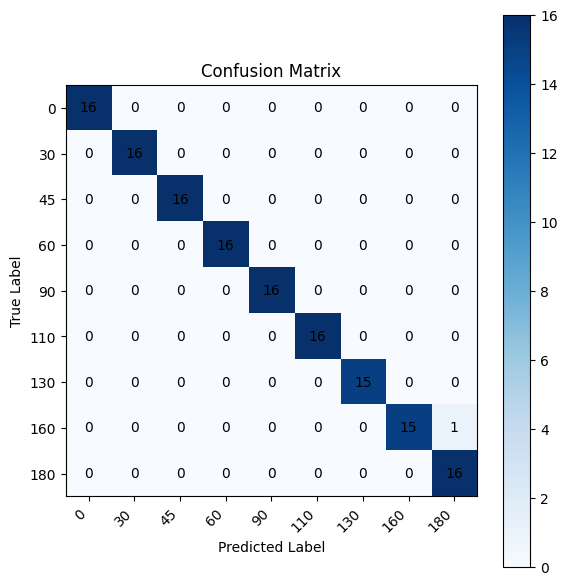

Saved trained model and scaler.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib

# ── Load and prepare data ─────────────────────────────────────────────────────
df = pd.read_csv('/content/datanew.csv')
X = df[['magnitude', 'smoothed', 'frequency']].values
y = df['angle'].values

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ── Scale features ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Train MLP ─────────────────────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred = mlp.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
labels = sorted(df['angle'].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Save model & scaler ───────────────────────────────────────────────────────
joblib.dump(mlp, 'mlp_datanew_model_scaled.joblib')
joblib.dump(scaler, 'scaler_datanew.joblib')
print("Saved trained model and scaler.")


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Test Accuracy: 99.30%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
          30       1.00      1.00      1.00        16
          45       1.00      1.00      1.00        16
          60       1.00      1.00      1.00        16
          90       1.00      1.00      1.00        16
         110       1.00      1.00      1.00        16
         130       1.00      1.00      1.00        15
         160       1.00      0.94      0.97        16
         180       0.94      1.00      0.97        16

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



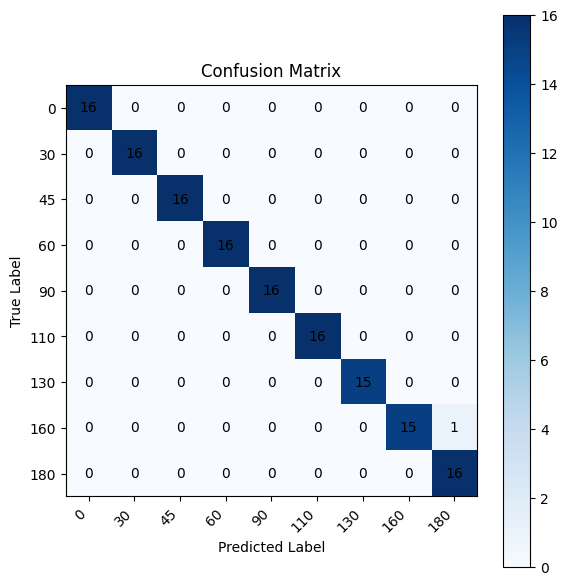

Saved trained model and scaler.
Exported weights & biases to weights_biases_datanew.txt


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib

# ── Load and prepare data ─────────────────────────────────────────────────────
df = pd.read_csv('/content/datanew.csv')
X = df[['magnitude', 'smoothed', 'frequency']].values
y = df['angle'].values

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ── Scale features ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Train MLP ─────────────────────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred = mlp.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
labels = sorted(df['angle'].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Save model & scaler ───────────────────────────────────────────────────────
joblib.dump(mlp, 'mlp_datanew_model_scaled.joblib')
joblib.dump(scaler, 'scaler_datanew.joblib')
print("Saved trained model and scaler.")

# ── Export weights & biases ───────────────────────────────────────────────────
wb_path = 'weights_biases_datanew.txt'
with open(wb_path, 'w') as f:
    for layer_idx, (coefs, intercepts) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
        f.write(f"=== Layer {layer_idx} ===\n")
        f.write("Weights:\n")
        # coefs shape: (n_inputs, n_neurons)
        # we want one line per neuron:
        #   for a neuron j: list coefs[i][j] over i
        n_inputs, n_neurons = coefs.shape
        for j in range(n_neurons):
            weights_j = [coefs[i, j] for i in range(n_inputs)]
            f.write(','.join(f"{w:.6f}" for w in weights_j) + '\n')
        f.write("Biases:\n")
        f.write(','.join(f"{b:.6f}" for b in intercepts) + '\n\n')
print(f"Exported weights & biases to {wb_path}")
